> This is the concise solution of Task 2 from the LittleBank Case Study. The Detailed Solution could be found in `LittleBank_Case_Study_ML` file. The concise solution is the best choice for the real-time interview.

> PS. Section 7 could also be ommited.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## 0. Load and Overview the Data

>The section is exactly the same as the `0. section` for the EDA solution (task 1).

In [4]:
df = pd.read_csv("/content/data/LittleBank_Case_Study.csv")

In [5]:
pd.set_option("display.max_columns", None)
df

,contact_id,month,day_of_week,contact,num_contacts,days_since_previous,num_contacts_previous,outcome_previous,age,marital,job,education,default,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome
0,32670,may,mon,mobile,2,-1,1,failure,51,married,industrial,4years,unknown,no,no,0.203883,28,13,1.299,23669.51229,-44.814,255.45575,-1.60866,False
1,8646,jun,wed,landline,5,-1,0,nonexistent,51,married,unemployed,4years,no,no,yes,0.779718,27,21,4.864,24268.31739,-40.546,259.77875,1.25118,False
2,6298,may,tue,landline,3,-1,0,nonexistent,43,married,industrial,4years,unknown,no,no,1.069440,23,14,4.857,24096.10290,-35.308,258.48350,0.98307,False
3,40424,aug,fri,mobile,2,-1,0,nonexistent,27,single,administrative,university.degree,no,yes,no,0.668203,25,25,0.905,23170.50804,-37.151,258.57425,-1.51929,True
4,26659,nov,thu,mobile,1,-1,0,nonexistent,36,single,professional,high.school,no,no,no,5.788102,16,8,4.076,24118.38402,-40.740,256.30000,-0.08937,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,30909,may,tue,mobile,1,-1,0,nonexistent,41,married,industrial,4years,unknown,yes,no,2.407597,24,14,1.344,23669.51229,-44.814,255.45575,-1.60866,False
34996,25744,nov,wed,mobile,1,-1,0,nonexistent,58,married,retired,9years,no,yes,no,1.247984,20,8,4.120,24118.38402,-40.740,256.30000,-0.08937,False
34997,39299,mar,wed,mobile,1,-1,0,nonexistent,23,single,full_time_education,high.school,no,no,no,1.279709,15,6,0.644,23249.88453,-33.756,256.76475,-1.60866,True
34998,18789,jul,thu,mobile,3,-1,0,nonexistent,25,single,full_time_education,high.school,no,no,no,0.817015,28,15,4.968,24268.31739,-41.419,258.27450,1.25118,False


In [6]:
df["outcome"] = df["outcome"].astype("string")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contact_id             35000 non-null  int64  
 1   month                  35000 non-null  object 
 2   day_of_week            35000 non-null  object 
 3   contact                35000 non-null  object 
 4   num_contacts           35000 non-null  int64  
 5   days_since_previous    35000 non-null  int64  
 6   num_contacts_previous  35000 non-null  int64  
 7   outcome_previous       35000 non-null  object 
 8   age                    35000 non-null  int64  
 9   marital                35000 non-null  object 
 10  job                    35000 non-null  object 
 11  education              35000 non-null  object 
 12  default                35000 non-null  object 
 13  mortgage               35000 non-null  object 
 14  personal_loan          35000 non-null  object 
 15  ca

In [8]:
df["outcome"].value_counts()            # From 35000 consumers only 3952 accepted the product, i.e. approx. 10%

,count
outcome,
False,31048
True,3952


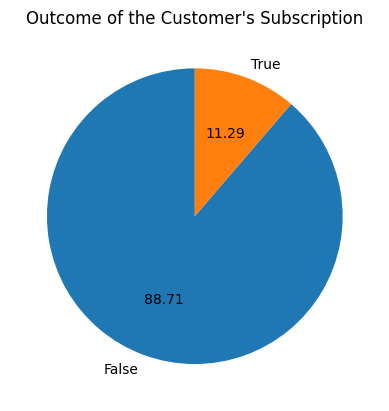

In [9]:
df["outcome"].value_counts().plot(kind = "pie", startangle = 90, autopct = "%1.2f")
plt.title("Outcome of the Customer's Subscription")
plt.ylabel("")
plt.show()

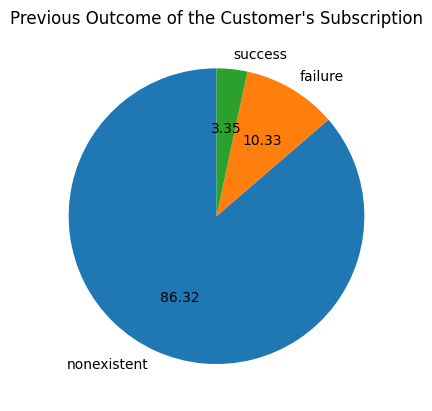

In [10]:
df["outcome_previous"].value_counts().plot(kind = "pie", startangle = 90, autopct = "%1.2f")
plt.title("Previous Outcome of the Customer's Subscription")
plt.ylabel("")
plt.show()

In [11]:
df["job"].value_counts()

,count
job,
administrative,8791
industrial,7880
technical,5786
professional,3367
management,2461
retired,1469
entrepreneur,1263
tradesman,1185
domestic,911


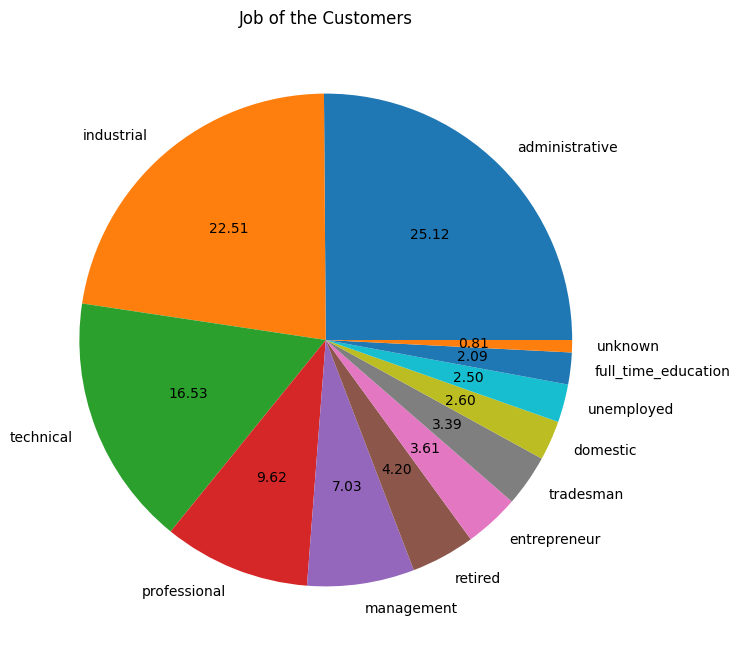

In [12]:
df["job"].value_counts().plot(kind = "pie", autopct = "%1.2f", figsize = (10, 8))
plt.title("Job of the Customers")
plt.ylabel("")
plt.show()

In [13]:
df["education"].describe()

,education
count,35000
unique,8
top,university.degree
freq,10319


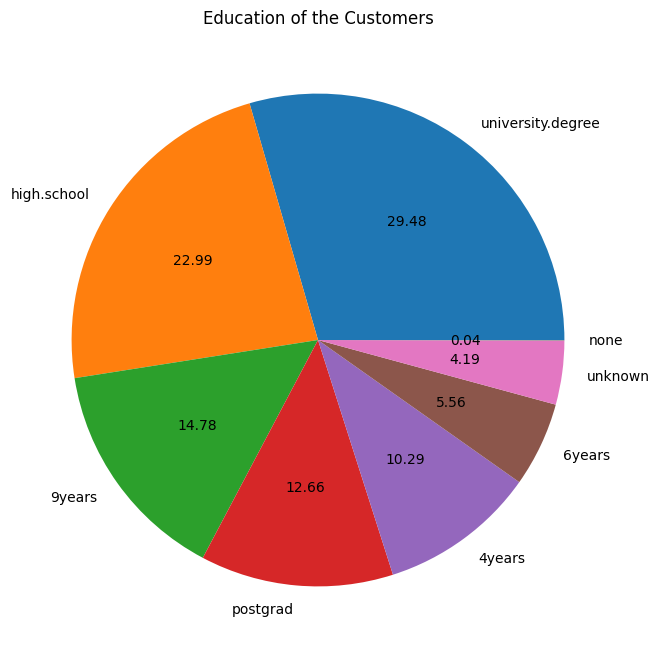

In [14]:
df["education"].value_counts().plot(kind = "pie", autopct = "%1.2f", figsize = (10, 8))
plt.title("Education of the Customers")
plt.ylabel("")
plt.show()

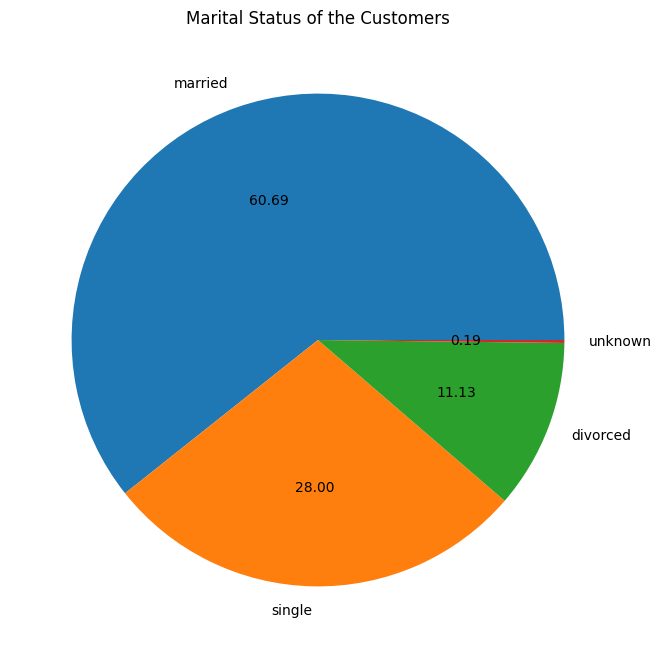

In [15]:
df["marital"].value_counts().plot(kind = "pie", autopct = "%1.2f", figsize = (10, 8))
plt.title("Marital Status of the Customers")
plt.ylabel("")
plt.show()

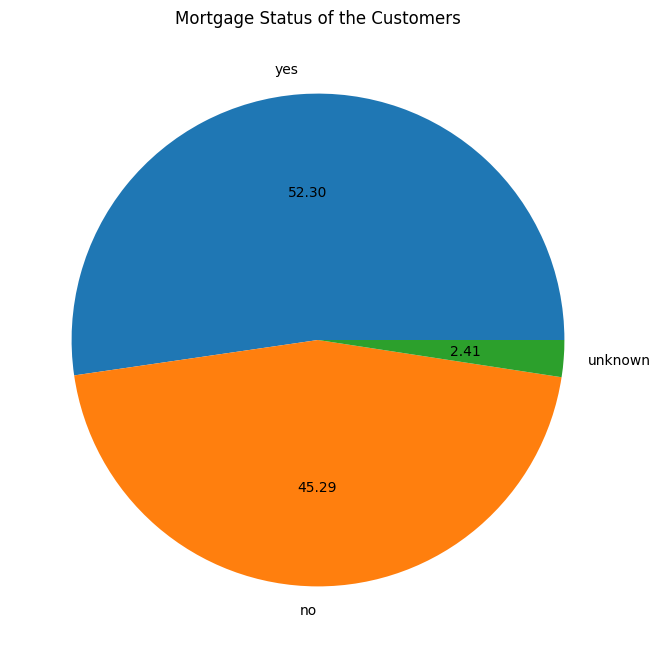

In [16]:
df["mortgage"].value_counts().plot(kind = "pie", autopct = "%1.2f", figsize = (10, 8))
plt.title("Mortgage Status of the Customers")
plt.ylabel("")
plt.show()

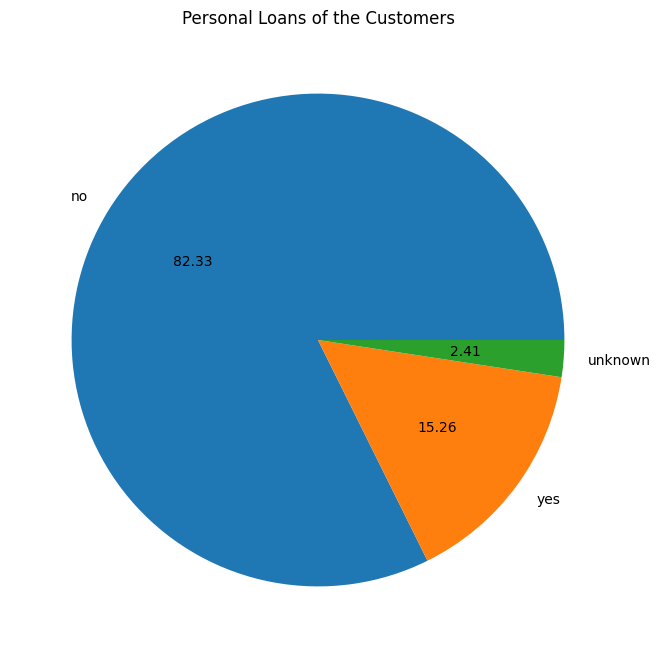

In [17]:
df["personal_loan"].value_counts().plot(kind = "pie", autopct = "%1.2f", figsize = (10, 8))
plt.title("Personal Loans of the Customers")
plt.ylabel("")
plt.show()

In [18]:
# df["num_contacts"].unique()
# df["outcome_previous"].unique()
df["default"].unique()

array(['unknown', 'no', 'yes'], dtype=object)

In [19]:
df["default"].value_counts()    # Default is not adding any value to the analysis;
                                # The Marketing was done only towards new clients

,count
default,
no,27653
unknown,7346
yes,1


In [20]:
df["outcome_previous"].value_counts()

,count
outcome_previous,
nonexistent,30213
failure,3614
success,1173


In [21]:
df["mortgage"].value_counts()

,count
mortgage,
yes,18304
no,15851
unknown,845


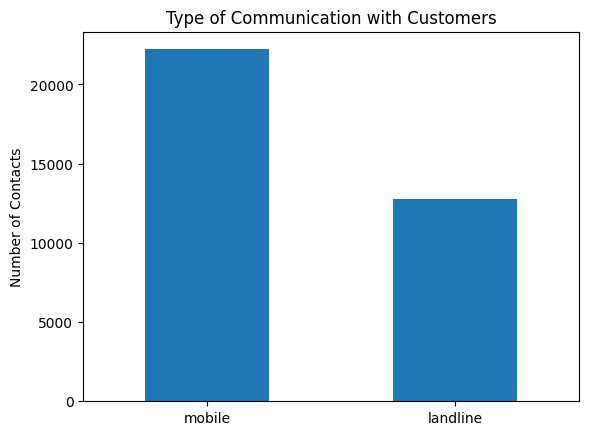

In [22]:
df["contact"].value_counts().plot(kind = "bar", xlabel = "", ylabel = "Number of Contacts",
                                  title = "Type of Communication with Customers",
                                  rot = 0);

## 1. Cleaning the Data

In [23]:
df_tr = df.copy()

### 1.1 Remove Duplicates and NaN Values

In [24]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contact_id             35000 non-null  int64  
 1   month                  35000 non-null  object 
 2   day_of_week            35000 non-null  object 
 3   contact                35000 non-null  object 
 4   num_contacts           35000 non-null  int64  
 5   days_since_previous    35000 non-null  int64  
 6   num_contacts_previous  35000 non-null  int64  
 7   outcome_previous       35000 non-null  object 
 8   age                    35000 non-null  int64  
 9   marital                35000 non-null  object 
 10  job                    35000 non-null  object 
 11  education              35000 non-null  object 
 12  default                35000 non-null  object 
 13  mortgage               35000 non-null  object 
 14  personal_loan          35000 non-null  object 
 15  ca

In [25]:
df_tr.loc[df_tr.isna().any(axis = "columns")].count()

,0
contact_id,0
month,0
day_of_week,0
contact,0
num_contacts,0
days_since_previous,0
num_contacts_previous,0
outcome_previous,0
age,0
marital,0


In [26]:
df_tr[df_tr.duplicated() == True]

,contact_id,month,day_of_week,contact,num_contacts,days_since_previous,num_contacts_previous,outcome_previous,age,marital,job,education,default,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome


In [27]:
df_tr.head()

,contact_id,month,day_of_week,contact,num_contacts,days_since_previous,num_contacts_previous,outcome_previous,age,marital,job,education,default,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome
0,32670,may,mon,mobile,2,-1,1,failure,51,married,industrial,4years,unknown,no,no,0.203883,28,13,1.299,23669.51229,-44.814,255.45575,-1.60866,False
1,8646,jun,wed,landline,5,-1,0,nonexistent,51,married,unemployed,4years,no,no,yes,0.779718,27,21,4.864,24268.31739,-40.546,259.77875,1.25118,False
2,6298,may,tue,landline,3,-1,0,nonexistent,43,married,industrial,4years,unknown,no,no,1.069440,23,14,4.857,24096.10290,-35.308,258.48350,0.98307,False
3,40424,aug,fri,mobile,2,-1,0,nonexistent,27,single,administrative,university.degree,no,yes,no,0.668203,25,25,0.905,23170.50804,-37.151,258.57425,-1.51929,True
4,26659,nov,thu,mobile,1,-1,0,nonexistent,36,single,professional,high.school,no,no,no,5.788102,16,8,4.076,24118.38402,-40.740,256.30000,-0.08937,False


### 1.2 Make Months and Days Column Numerical

In [28]:
months_unique = df_tr.month.unique()
days_unique = df_tr.day_of_week.unique()
months_unique, days_unique

(array(['may', 'jun', 'aug', 'nov', 'jul', 'sep', 'apr', 'oct', 'mar',
        'dec'], dtype=object),
 array(['mon', 'wed', 'tue', 'fri', 'thu'], dtype=object))

In [29]:
days_of_the_week = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
months_in_the_year = ["jan", "feb", "mar", "apr", "may", "jun",
                      "jul", "aug","sep", "oct", "nov", "dec"]

# A dictionary that maps the day with the corresponding number of the day in a week
days_of_the_week_dict = {day:i for i, day in enumerate(days_of_the_week, start = 1)}

# A dictionary that maps the month with the corresponding number of the month in the year
months_in_the_year_dict = {month_str:i for i, month_str in enumerate(months_in_the_year, start = 1)}

In [30]:
#df_tr['month'].map(months_in_the_year_dict)

In [31]:
# Insert a new column in the data frame that maps the months with the corresponding number
df_tr.insert(loc = 2, column = "month_no", value = df_tr['month'].map(months_in_the_year_dict))
df_tr.insert(loc = 4, column = "day_of_week_no", value = df_tr['day_of_week'].map(days_of_the_week_dict))

### 1.3 Delete Insignificant Columns and Incorrect Values

In [32]:
df_tr.drop(labels = ["month", "day_of_week"], axis = 1, inplace = True)
#df_tr

In [33]:
df_tr.drop(labels = ["days_since_previous", "num_contacts_previous", "default"], axis = 1, inplace = True)

In [34]:
df_tr[df_tr["job"] == "unknown"].index

Index([   15,   139,   347,   520,   541,   559,   694,   716,   795,   942,
       ...
       33982, 33994, 34045, 34257, 34375, 34592, 34671, 34760, 34798, 34939],
      dtype='int64', length=283)

In [35]:
df_tr.drop(index = (df_tr[df_tr["marital"] == "unknown"]).index, inplace = True)
df_tr.drop(index = (df_tr[df_tr["job"] == "unknown"]).index, inplace = True)
df_tr.drop(index = (df_tr[df_tr["education"] == "unknown"]).index, inplace = True)
df_tr.drop(index = (df_tr[df_tr["mortgage"] == "unknown"]).index, inplace = True)
df_tr.drop(index = (df_tr[df_tr["personal_loan"] == "unknown"]).index, inplace = True)

In [36]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32503 entries, 0 to 34998
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   contact_id            32503 non-null  int64  
 1   month_no              32503 non-null  int64  
 2   day_of_week_no        32503 non-null  int64  
 3   contact               32503 non-null  object 
 4   num_contacts          32503 non-null  int64  
 5   outcome_previous      32503 non-null  object 
 6   age                   32503 non-null  int64  
 7   marital               32503 non-null  object 
 8   job                   32503 non-null  object 
 9   education             32503 non-null  object 
 10  mortgage              32503 non-null  object 
 11  personal_loan         32503 non-null  object 
 12  call_centre_volume    32503 non-null  float64
 13  high_temp             32503 non-null  int64  
 14  low_temp              32503 non-null  int64  
 15  forward_rate          32

### 1.4 Delete Samples that have Extreme Values

In [37]:
df_tr.describe().T

,count,mean,std,min,25%,50%,75%,max
contact_id,32503.0,20669.421684,11833.729744,0.000000,10440.500000,20815.000000,30896.500000,41187.000000
month_no,32503.0,6.619235,2.052595,3.000000,5.000000,6.000000,8.000000,12.000000
day_of_week_no,32503.0,2.978340,1.411347,1.000000,2.000000,3.000000,4.000000,5.000000
num_contacts,32503.0,2.566132,2.783424,1.000000,1.000000,2.000000,3.000000,43.000000
age,32503.0,39.882657,10.325010,17.000000,32.000000,38.000000,47.000000,98.000000
call_centre_volume,32503.0,1.196796,1.097099,0.000188,0.411167,0.888796,1.651421,12.263099
high_temp,32503.0,25.247762,4.606014,10.000000,22.000000,25.000000,28.000000,42.000000
low_temp,32503.0,15.297511,4.984164,2.000000,11.000000,14.000000,20.000000,29.000000
forward_rate,32503.0,3.619532,1.731566,0.634000,1.344000,4.857000,4.961000,5.045000
num_employed,32503.0,23985.657642,333.686525,23040.534840,23669.512290,24096.102900,24268.317390,24268.317390


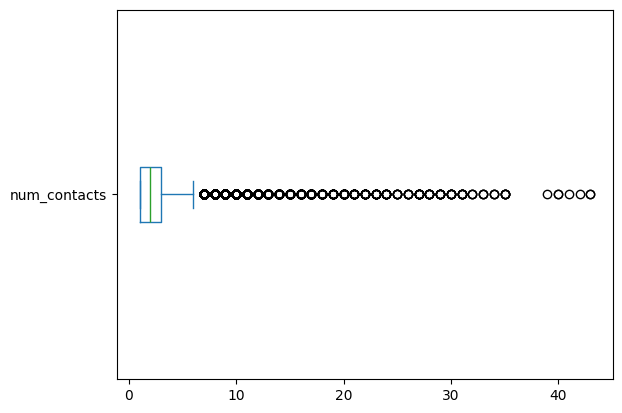

In [38]:
df_tr["num_contacts"].plot(kind = "box", vert = False);

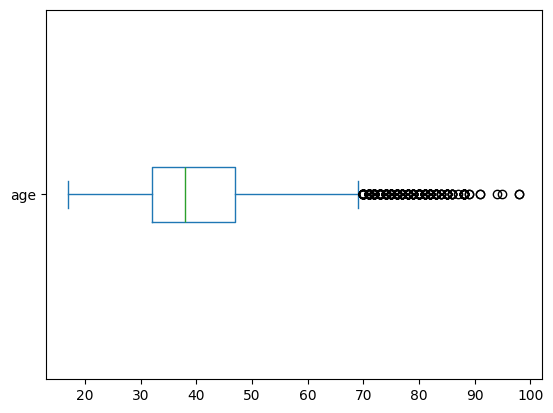

In [39]:
df_tr["age"].plot(kind = "box", vert = False);

In [40]:
df_tr = df_tr[(df_tr["num_contacts"] < 10) & (df_tr["age"] < 86)]
df_tr

,contact_id,month_no,day_of_week_no,contact,num_contacts,outcome_previous,age,marital,job,education,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome
0,32670,5,1,mobile,2,failure,51,married,industrial,4years,no,no,0.203883,28,13,1.299,23669.51229,-44.814,255.45575,-1.60866,False
1,8646,6,3,landline,5,nonexistent,51,married,unemployed,4years,no,yes,0.779718,27,21,4.864,24268.31739,-40.546,259.77875,1.25118,False
2,6298,5,2,landline,3,nonexistent,43,married,industrial,4years,no,no,1.069440,23,14,4.857,24096.10290,-35.308,258.48350,0.98307,False
3,40424,8,5,mobile,2,nonexistent,27,single,administrative,university.degree,yes,no,0.668203,25,25,0.905,23170.50804,-37.151,258.57425,-1.51929,True
4,26659,11,4,mobile,1,nonexistent,36,single,professional,high.school,no,no,5.788102,16,8,4.076,24118.38402,-40.740,256.30000,-0.08937,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34994,4850,5,3,landline,1,nonexistent,57,married,technical,high.school,no,no,0.525146,27,11,4.858,24096.10290,-35.308,258.48350,0.98307,False
34995,30909,5,2,mobile,1,nonexistent,41,married,industrial,4years,yes,no,2.407597,24,14,1.344,23669.51229,-44.814,255.45575,-1.60866,False
34996,25744,11,3,mobile,1,nonexistent,58,married,retired,9years,yes,no,1.247984,20,8,4.120,24118.38402,-40.740,256.30000,-0.08937,False
34997,39299,3,3,mobile,1,nonexistent,23,single,full_time_education,high.school,no,no,1.279709,15,6,0.644,23249.88453,-33.756,256.76475,-1.60866,True


In [41]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31608 entries, 0 to 34998
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   contact_id            31608 non-null  int64  
 1   month_no              31608 non-null  int64  
 2   day_of_week_no        31608 non-null  int64  
 3   contact               31608 non-null  object 
 4   num_contacts          31608 non-null  int64  
 5   outcome_previous      31608 non-null  object 
 6   age                   31608 non-null  int64  
 7   marital               31608 non-null  object 
 8   job                   31608 non-null  object 
 9   education             31608 non-null  object 
 10  mortgage              31608 non-null  object 
 11  personal_loan         31608 non-null  object 
 12  call_centre_volume    31608 non-null  float64
 13  high_temp             31608 non-null  int64  
 14  low_temp              31608 non-null  int64  
 15  forward_rate          31

In [42]:
df_tr_sorted = df_tr.sort_values(by = ["month_no", "day_of_week_no"])

In [43]:
# Store the file after the data cleaning
#df_tr.to_csv("LittleBank_Case_Study_Cleaned.csv", index=False)

### 1.5 Make Outcome Column Numerical

In [44]:
from sklearn.preprocessing import LabelEncoder

target = df_tr["outcome"]

enc_labels = LabelEncoder()
df_tr["outcome_encoded"] = enc_labels.fit_transform(target)

In [45]:
df_tr["outcome_encoded"].value_counts()

,count
outcome_encoded,
0,28025
1,3583


## 2. Analyze Distribution of Data and Features

### 2.1 Overview Outcome Target Column

In [46]:
df_tr["outcome"].value_counts()

,count
outcome,
False,28025
True,3583


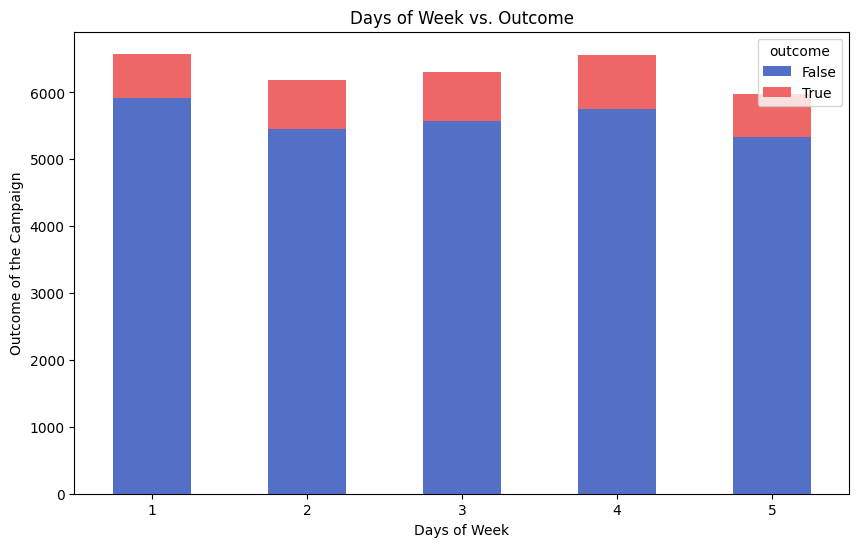

In [47]:
df_tr_day = df_tr_sorted.pivot_table(index = "day_of_week_no",
                                     columns = "outcome",
                                     aggfunc = "size")

df_tr_day.plot(kind = "bar", stacked = True, color=['#5470C6', '#EE6666'], figsize=(10, 6))

plt.xlabel("Days of Week")
plt.ylabel("Outcome of the Campaign")
plt.title("Days of Week vs. Outcome")
plt.xticks(rotation = 0)
plt.show()

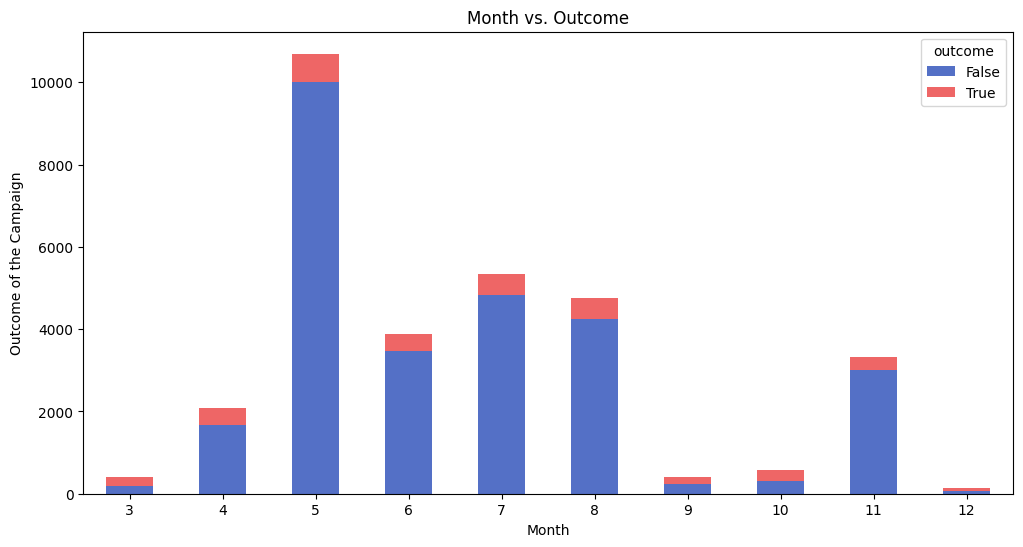

In [48]:
df_tr_day = df_tr_sorted.pivot_table(index = "month_no",
                                     columns = "outcome",
                                     aggfunc = "size")

df_tr_day.plot(kind = "bar", stacked = True, color=['#5470C6', '#EE6666'], figsize=(12, 6))

plt.xlabel("Month")
plt.ylabel("Outcome of the Campaign")
plt.title("Month vs. Outcome")
plt.xticks(rotation = 0)
#plt.tight_layout()
plt.show()

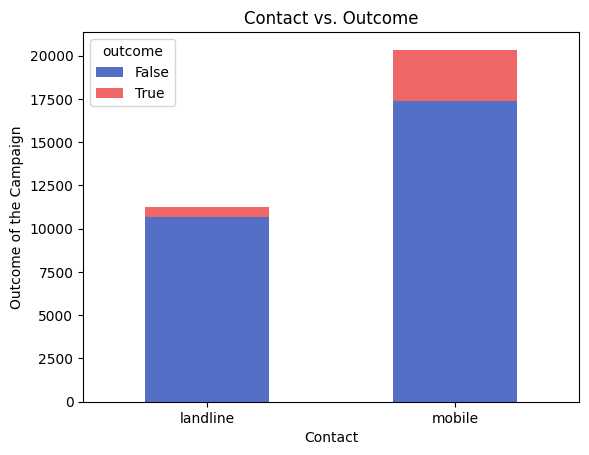

In [49]:
df_tr_day = df_tr_sorted.pivot_table(index = "contact",
                                     columns = "outcome",
                                     aggfunc = "size")

df_tr_day.plot(kind = "bar", stacked = True, color=['#5470C6', '#EE6666'])

plt.xlabel("Contact")
plt.ylabel("Outcome of the Campaign")
plt.title("Contact vs. Outcome")
plt.xticks(rotation = 0)
#plt.tight_layout()
plt.show()

### 2.2 Correlation

In [50]:
df_tr_corr_numerical = df_tr.select_dtypes(include = ["number"]).corr()

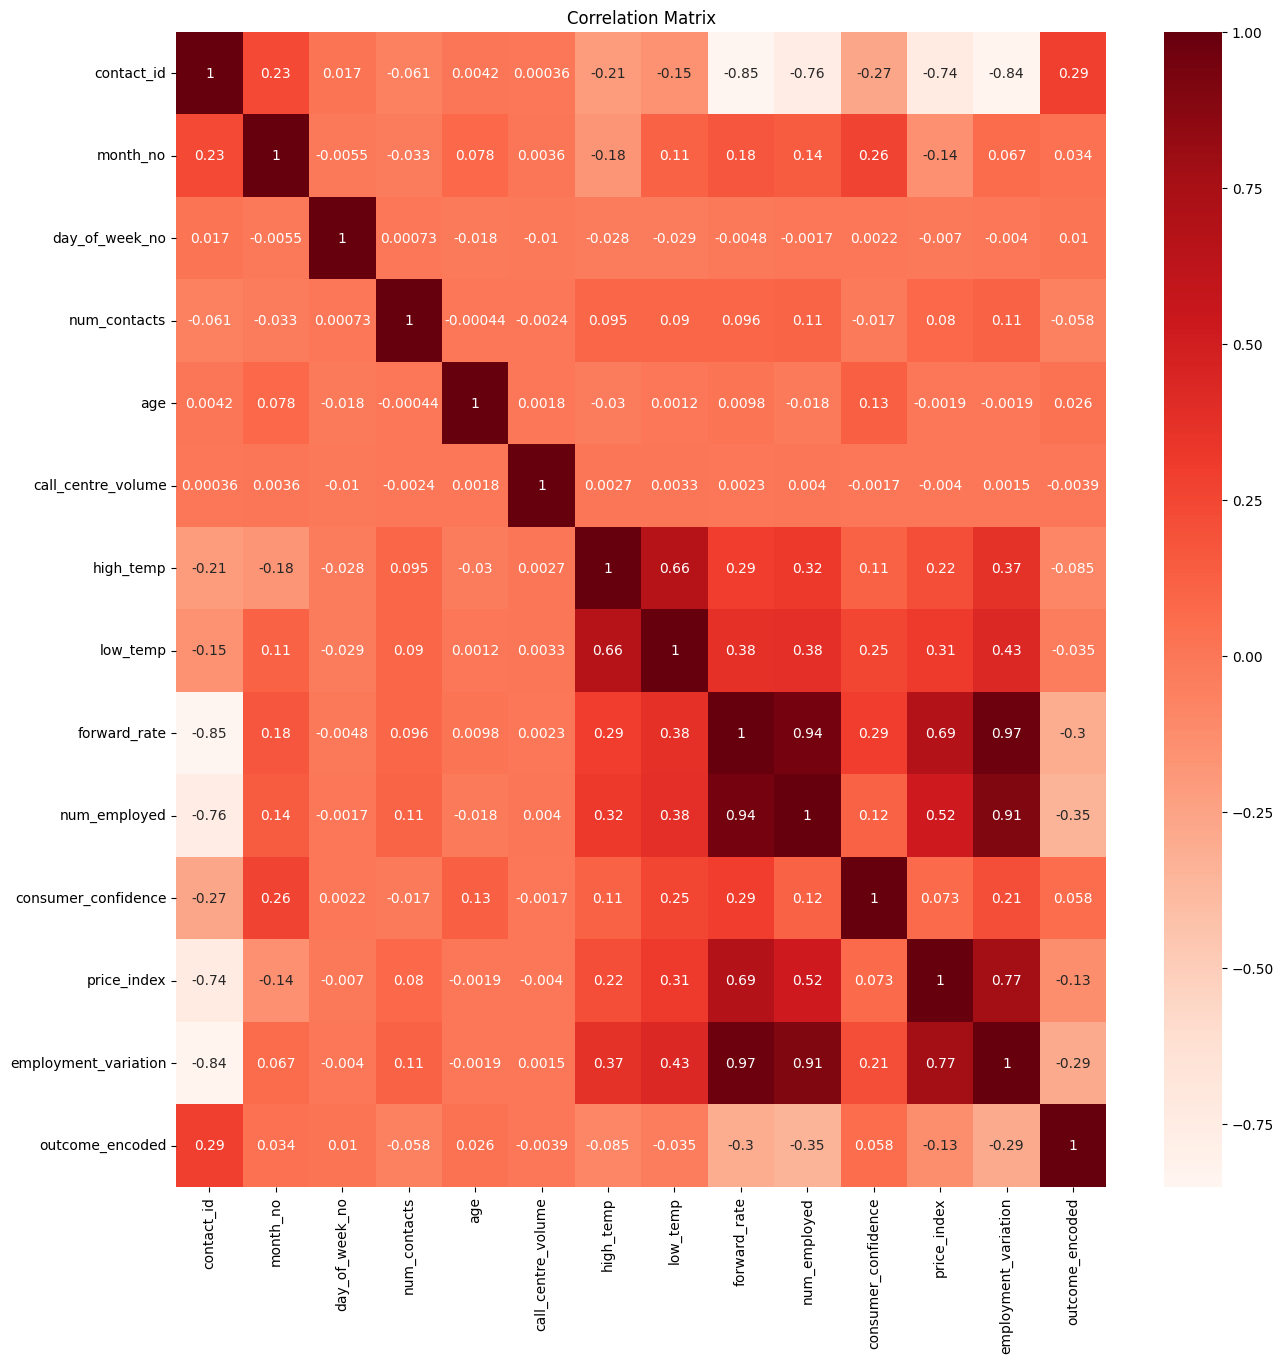

In [51]:
fig, ax = plt.subplots(figsize = (15, 15))

sns.heatmap(df_tr_corr_numerical, cmap = "Reds", annot = True, ax = ax)

plt.title("Correlation Matrix")
plt.show()

## 3. Train and Test Split

### 3.1 Tackle Data Imbalance

The data for the LittleBank campaign is imbalanced. Near 90% of the data consists of people who didn't subscribe for the savings account. Only 10% of the people accepted the offer and opened a classic savings account. As a result, the smaller class with the people who subscribed will often be misclassified. There is also a bias towards the people who didn't subscribe. To address these problems, a few techniques could be applied:

1. Under-sampling techniques - decrease the number of samples in the majority class

2. Over-sampling - increase the number of samples in the minority class

The most famous sampling techniques are:

* Random Over-Sampling

* SMOTE (Synthetic Minority Over-sampling Technique)

* ADASYN (Adaptive Synthetic Sampling)

The SMOTE technique was implemented in the notebook. It improves the classification of the minority class. Another benefit of SMOTE is the improvement of the ML model's variance. A disadvantage of the approach is the computational cost of the technique. However, in our case, it could be omitted because the data is relatively small.

Feel free to implement the other two over-sampling techniques and observe the result of the ML models. They could lead to better results in other tasks.

In [52]:
from imblearn.over_sampling import SMOTENC

In [53]:
df_tr.columns

Index(['contact_id', 'month_no', 'day_of_week_no', 'contact', 'num_contacts',
       'outcome_previous', 'age', 'marital', 'job', 'education', 'mortgage',
       'personal_loan', 'call_centre_volume', 'high_temp', 'low_temp',
       'forward_rate', 'num_employed', 'consumer_confidence', 'price_index',
       'employment_variation', 'outcome', 'outcome_encoded'],
      dtype='object')

In [54]:
input_cols_df = df_tr.columns[:-2]
target_col_df = df_tr.columns[-1]

In [55]:
X = df_tr[input_cols_df].copy()
y = df_tr[target_col_df].copy()

X.shape, y.shape

((31608, 20), (31608,))

In [56]:
categorical_cols_df = X.select_dtypes("object").columns.tolist()
categorical_cols_df

['contact',
 'outcome_previous',
 'marital',
 'job',
 'education',
 'mortgage',
 'personal_loan']

In [57]:
smote = SMOTENC(categorical_features = categorical_cols_df, sampling_strategy = "auto", random_state = 42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_resampled.shape, y_resampled.shape

((56050, 20), (56050,))

In [58]:
df_tr_resampled = pd.concat([X_resampled, y_resampled], axis = 1)

In [59]:
df_tr_resampled

,contact_id,month_no,day_of_week_no,contact,num_contacts,outcome_previous,age,marital,job,education,mortgage,personal_loan,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,outcome_encoded
0,32670,5,1,mobile,2,failure,51,married,industrial,4years,no,no,0.203883,28,13,1.299,23669.51229,-44.814,255.45575,-1.60866,0
1,8646,6,3,landline,5,nonexistent,51,married,unemployed,4years,no,yes,0.779718,27,21,4.864,24268.31739,-40.546,259.77875,1.25118,0
2,6298,5,2,landline,3,nonexistent,43,married,industrial,4years,no,no,1.069440,23,14,4.857,24096.10290,-35.308,258.48350,0.98307,0
3,40424,8,5,mobile,2,nonexistent,27,single,administrative,university.degree,yes,no,0.668203,25,25,0.905,23170.50804,-37.151,258.57425,-1.51929,1
4,26659,11,4,mobile,1,nonexistent,36,single,professional,high.school,no,no,5.788102,16,8,4.076,24118.38402,-40.740,256.30000,-0.08937,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56045,37578,8,5,mobile,3,nonexistent,33,married,unemployed,postgrad,no,no,2.352707,28,19,0.869,23563.21278,-30.458,253.55275,-2.59173,1
56046,19522,8,4,mobile,4,nonexistent,32,married,technical,high.school,yes,no,0.388883,32,20,4.968,24268.31739,-35.017,256.97100,1.25118,1
56047,40193,7,1,mobile,1,nonexistent,23,single,technical,university.degree,yes,no,1.208258,29,20,0.870,23170.50804,-39.091,259.09125,-1.51929,1
56048,34529,5,4,mobile,1,nonexistent,28,single,administrative,high.school,no,no,0.694698,25,13,1.266,23669.51229,-44.814,255.45575,-1.60866,1


### 3.2 Split the Data into Train and Test Split

In [60]:
train_df, test_df = train_test_split(df_tr_resampled, test_size = 0.2, random_state = 42)

train_df.shape, test_df.shape

((44840, 21), (11210, 21))

In [61]:
df_tr.columns

Index(['contact_id', 'month_no', 'day_of_week_no', 'contact', 'num_contacts',
       'outcome_previous', 'age', 'marital', 'job', 'education', 'mortgage',
       'personal_loan', 'call_centre_volume', 'high_temp', 'low_temp',
       'forward_rate', 'num_employed', 'consumer_confidence', 'price_index',
       'employment_variation', 'outcome', 'outcome_encoded'],
      dtype='object')

In [62]:
input_cols = ["month_no", "day_of_week_no", "contact", "num_contacts",
              "age", "marital", "job", "education", "mortgage",
              "personal_loan", "call_centre_volume", "high_temp", "low_temp",
              "forward_rate", "num_employed", "consumer_confidence", "price_index",
              "employment_variation"]
target_col = "outcome_encoded"

In [63]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [64]:
test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

In [65]:
numeric_cols = train_inputs.select_dtypes(include = ["number"]).columns.tolist()        # np.number
categorical_cols = train_inputs.select_dtypes("object").columns.tolist()

In [66]:
train_inputs[categorical_cols].nunique()

,0
contact,2
marital,3
job,11
education,7
mortgage,2
personal_loan,2


## 4. Pre-processing the Data

### 4.1 Scale

In [67]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df_tr[numeric_cols])

MinMaxScaler()

In [68]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [69]:
train_inputs.describe()

,month_no,day_of_week_no,num_contacts,age,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation
count,44840.000000,44840.000000,44840.000000,44840.000000,44840.000000,44840.000000,44840.000000,44840.000000,44840.000000,44840.000000,44840.000000,44840.000000
mean,0.412452,0.484038,0.122092,0.335429,0.096951,0.453791,0.475752,0.525926,0.648800,0.443553,0.494197,0.602366
std,0.246573,0.343686,0.178076,0.161679,0.082424,0.150092,0.191510,0.427656,0.327286,0.225197,0.246787,0.357637
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.250000,0.000000,0.220588,0.038769,0.343750,0.333333,0.138291,0.425709,0.338912,0.269680,0.333333
50%,0.333333,0.500000,0.000000,0.294118,0.074838,0.468750,0.444444,0.767853,0.859735,0.376569,0.484412,0.687500
75%,0.555556,0.750000,0.125000,0.441176,0.131149,0.562500,0.629630,0.980277,1.000000,0.602510,0.698753,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [70]:
test_inputs[numeric_cols]

,month_no,day_of_week_no,num_contacts,age,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation
19224,0.888889,0.75,0.250,0.279412,0.166750,0.21875,0.222222,0.780322,0.877883,0.368201,0.389322,0.687500
2710,0.444444,0.75,0.625,0.294118,0.138392,0.81250,0.703704,0.980277,1.000000,0.338912,0.669135,1.000000
16904,0.555556,0.50,0.125,0.411765,0.117696,0.56250,0.740741,0.981637,1.000000,0.615063,0.484412,1.000000
50629,0.111111,0.50,0.125,0.294118,0.152861,0.37500,0.259259,0.177057,0.512287,0.154812,0.340608,0.333333
34676,0.333333,0.75,0.125,0.235294,0.206293,0.56250,0.592593,0.979184,1.000000,0.376569,0.882307,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
23861,0.444444,0.75,0.250,0.250000,0.013962,0.71875,0.629630,0.060077,0.105860,0.439331,0.784879,0.354167
41761,0.111111,0.50,0.000,0.352941,0.046021,0.31250,0.222222,0.177057,0.512287,0.154812,0.340608,0.333333
12617,0.444444,0.75,0.000,0.602941,0.013819,0.59375,0.592593,0.981183,1.000000,0.338912,0.669135,1.000000
15262,0.888889,0.00,0.125,0.294118,0.042334,0.15625,0.222222,0.806393,0.877883,0.368201,0.389322,0.687500


### 4.2 Encoding Categorical Data

In [71]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore")
encoder.fit(df_tr[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [72]:
encoder.categories_

[array(['landline', 'mobile'], dtype=object),
 array(['divorced', 'married', 'single'], dtype=object),
 array(['administrative', 'domestic', 'entrepreneur',
        'full_time_education', 'industrial', 'management', 'professional',
        'retired', 'technical', 'tradesman', 'unemployed'], dtype=object),
 array(['4years', '6years', '9years', 'high.school', 'none', 'postgrad',
        'university.degree'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object)]

In [73]:
train_inputs[categorical_cols].columns

Index(['contact', 'marital', 'job', 'education', 'mortgage', 'personal_loan'], dtype='object')

In [74]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

# Remove "." character from the Column Names
trans_table = str.maketrans(".", "_")
encoded_cols = [col.translate(trans_table) for col in encoded_cols]
print(encoded_cols)

['contact_landline', 'contact_mobile', 'marital_divorced', 'marital_married', 'marital_single', 'job_administrative', 'job_domestic', 'job_entrepreneur', 'job_full_time_education', 'job_industrial', 'job_management', 'job_professional', 'job_retired', 'job_technical', 'job_tradesman', 'job_unemployed', 'education_4years', 'education_6years', 'education_9years', 'education_high_school', 'education_none', 'education_postgrad', 'education_university_degree', 'mortgage_no', 'mortgage_yes', 'personal_loan_no', 'personal_loan_yes']


In [75]:
train_inputs = pd.concat([train_inputs[numeric_cols], pd.DataFrame(encoder.transform(train_inputs[categorical_cols]), columns=encoded_cols, index=train_inputs.index)], axis=1)
test_inputs = pd.concat([test_inputs[numeric_cols], pd.DataFrame(encoder.transform(test_inputs[categorical_cols]), columns=encoded_cols, index=test_inputs.index)], axis=1)

In [76]:
train_inputs

,month_no,day_of_week_no,num_contacts,age,call_centre_volume,high_temp,low_temp,forward_rate,num_employed,consumer_confidence,price_index,employment_variation,contact_landline,contact_mobile,marital_divorced,marital_married,marital_single,job_administrative,job_domestic,job_entrepreneur,job_full_time_education,job_industrial,job_management,job_professional,job_retired,job_technical,job_tradesman,job_unemployed,education_4years,education_6years,education_9years,education_high_school,education_none,education_postgrad,education_university_degree,mortgage_no,mortgage_yes,personal_loan_no,personal_loan_yes
37424,0.333333,0.25,0.250,0.191176,0.021155,0.37500,0.555556,0.980957,1.000000,0.376569,0.882307,1.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
50297,0.444444,0.00,0.000,0.617647,0.079903,0.65625,0.703704,0.043778,0.105860,0.439331,0.784879,0.354167,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
53029,0.333333,0.00,0.000,0.323529,0.074535,0.37500,0.481481,0.143278,0.425709,0.418410,0.296960,0.104167,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
31091,0.222222,0.50,0.125,0.264706,0.180120,0.46875,0.407407,0.957379,0.859735,0.602510,0.698753,0.937500,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
32827,0.444444,0.50,0.250,0.220588,0.058806,0.75000,0.629630,0.089549,0.425709,0.719665,0.104443,0.104167,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44732,0.222222,0.00,0.125,0.367647,0.166112,0.43750,0.333333,0.957379,0.859735,0.602510,0.698753,0.937500,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
54343,0.333333,0.25,0.000,0.455882,0.165896,0.37500,0.629630,0.980957,1.000000,0.376569,0.882307,1.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
38158,0.222222,1.00,0.250,0.323529,0.029108,0.50000,0.370370,0.010882,0.170510,0.451883,0.652767,0.333333,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
860,0.777778,0.00,0.000,0.235294,0.063625,0.34375,0.296296,0.021990,0.203781,1.000000,0.089634,0.000000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 5. Save Data Frames

In [77]:
import os
from pathlib import Path

save_files_dir = Path("save/")

if save_files_dir.is_dir():
    print(f"The {save_files_dir} directory exists.")
else:
    print(f"{save_files_dir} directory do not exists. Creating one...")
    save_files_dir.mkdir(parents = True, exist_ok = True)
    print(f"{save_files_dir} directory is created.")

save directory do not exists. Creating one...
save directory is created.


In [78]:
train_inputs.to_parquet("save/train_inputs.parquet")
test_inputs.to_parquet("save/test_inputs.parquet")

In [79]:
pd.DataFrame(train_targets).to_parquet("save/train_target.parquet")
pd.DataFrame(test_targets).to_parquet("save/test_target.parquet")

## 6. Base Models

### 6.1 Random Guesses and All Negative Models

In [80]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

In [81]:
def random_guess(inputs):
    return np.random.choice([0, 1], len(inputs))

In [82]:
test_acc_random = accuracy_score(test_targets, random_guess(test_inputs))
recall_test_random = recall_score(test_targets, random_guess(test_inputs))
precision_test_random = precision_score(test_targets, random_guess(test_inputs))

print("Metrics to beat...")
print(f"Accuracy = {test_acc_random}, Recall = {recall_test_random}, Precision = {precision_test_random}")

Metrics to beat...
Accuracy = 0.5016057091882248, Recall = 0.4952122854561879, Precision = 0.4961970300615719


In [83]:
def all_output_negative(inputs):
    return np.full(len(inputs), 0)

In [84]:
accuracy_score(test_targets, all_output_negative(test_inputs))

0.5062444246208743

### 6.2 Logistic Regression

#### 6.2.1 Simple Model for Finding the Best Hyperparameters

In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import precision_recall_fscore_support

model_log_regr_temp = LogisticRegression(C = 0.98, solver = "lbfgs", n_jobs = -1, max_iter = 500)

model_log_regr_temp.fit(train_inputs, train_targets)

train_preds = model_log_regr_temp.predict(train_inputs)
test_preds = model_log_regr_temp.predict(test_inputs)
train_acc = accuracy_score(train_targets, train_preds)
test_acc = accuracy_score(test_targets, test_preds)

precision, recall, f1score, _ = precision_recall_fscore_support(test_targets, test_preds, pos_label = 1, average = "binary")
print(f"Train Accuracy = {train_acc:.5f} Test Accuracy = {test_acc:.5f}, Precision = {precision:.5f}, Recall = {recall:.5f}, F1_Score = {f1score:.5f}")

Train Accuracy = 0.75123 Test Accuracy = 0.76039, Precision = 0.77580, Recall = 0.72394, F1_Score = 0.74897


### 6.2.2 Find the Best Parameters via Grid Search

In [100]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_fscore_support

param_grid = {
    #"penalty": ["elasticnet"],         # "l1", "l2", "elasticnet"
    "C": [0.1, 0.98, 1],                # np.arange(0.01, 1.01, 0.01); np.arange(1, 10.25, 0.25)
    "solver": ["lbfgs"],                # ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"],
    "n_jobs": [-1],
    "max_iter": [500],
    #"l1_ratio": np.arange(0, 1.01, 0.01)
}

model_log_regr_simple = LogisticRegression()

grid_search_log_regr = GridSearchCV(estimator = model_log_regr_simple,
                                    param_grid = param_grid,
                                    scoring = ["accuracy", "recall", "precision"],      # Test only one scoring...
                                    n_jobs = -1,
                                    refit = "accuracy",                                 # Accuracy if the classes are balanced, Recall if you use unbalanced data
                                    cv = 5,
                                    verbose = 3)

In [101]:
clf = grid_search_log_regr.fit(train_inputs, train_targets)

clf.best_estimator_

Fitting 5 folds for each of 3 candidates, totalling 15 fits


LogisticRegression(C=0.98, max_iter=500, n_jobs=-1)

In [102]:
clf.best_params_, clf.best_score_

({'C': 0.98, 'max_iter': 500, 'n_jobs': -1, 'solver': 'lbfgs'},
 np.float64(0.7512488849241749))

In [103]:
temp_best_model = clf.best_estimator_
test_preds = temp_best_model.predict(test_inputs)

test_acc = accuracy_score(test_targets, test_preds)

precision, recall, f1score, _ = precision_recall_fscore_support(test_targets, test_preds, pos_label = 1, average = "binary")
print(f"Test Accuracy = {test_acc:.5f}, Precision = {precision:.5f}, Recall = {recall:.5f}, F1_Score = {f1score:.5f}")

Test Accuracy = 0.76039, Precision = 0.77580, Recall = 0.72394, F1_Score = 0.74897


In [104]:
## Without Data Resampling
# Train Accuracy: 0.89018    Test Accuracy: 0.89718
# Recall = 0.20546, Precision = 0.59583

In [105]:
## SMOTE Data Resampling
# Train Accuracy = 0.75123, Test Accuracy = 0.76039
# Recall = 0.72394, Precision = 0.77580

### 6.3 Bonus Functions

In [106]:
def calculate_basic_metrics(targets, preds):
    accuracy = accuracy_score(targets, preds)
    recall = recall_score(targets, preds)#, pos_label = "True")
    precision = precision_score(targets, preds)#, pos_label = "True")

    return accuracy, recall, precision

## 7. Lasso and ElasticNet Model

### 7.1 Lasso

In [143]:
#from sklearn.linear_model import LogisticRegression

model_lasso = LogisticRegression(penalty = "l1", C = 1, solver = "saga", n_jobs = -1, max_iter = 500)

model_lasso.fit(train_inputs, train_targets)

LogisticRegression(C=1, max_iter=500, n_jobs=-1, penalty='l1', solver='saga')

In [144]:
train_preds_lasso = model_lasso.predict(train_inputs)
test_preds_lasso = model_lasso.predict(test_inputs)

In [145]:
calculate_basic_metrics(train_targets, train_preds_lasso)

(0.7518733273862622, 0.7065362383281458, 0.7783111285266457)

In [146]:
train_acc = accuracy_score(train_targets, train_preds_lasso)
test_acc, recall_test, precision_test = calculate_basic_metrics(test_targets, test_preds_lasso)

In [147]:
print(f"Train Accuracy = {train_acc:.5f}, Test Accuracy = {test_acc:.5f}")
print(f"Recall = {recall_test:.5f}, Precision = {precision_test:.5f}")

Train Accuracy = 0.75187, Test Accuracy = 0.76021
Recall = 0.72213, Precision = 0.77657


In [112]:
## Without Data Resampling
# Train Accuracy = 0.89018, Test Accuracy = 0.89718
# Recall = 0.21408, Precision = 0.59583

In [113]:
## SMOTE Data Resampling
# Train Accuracy = 0.75123, Test Accuracy = 0.76030
# Recall = 0.72231, Precision = 0.77661

### 7.2 ElasticNet

In [148]:
model_elastic_net = LogisticRegression(penalty = "elasticnet",
                                         C = 1,
                                         solver = "saga",
                                         n_jobs = -1,
                                         max_iter = 500,
                                         l1_ratio = 0.6)

model_elastic_net.fit(train_inputs, train_targets)

LogisticRegression(C=1, l1_ratio=0.6, max_iter=500, n_jobs=-1,
                   penalty='elasticnet', solver='saga')

In [149]:
train_preds_enet = model_elastic_net.predict(train_inputs)

test_preds_enet = model_elastic_net.predict(test_inputs)

In [150]:
calculate_basic_metrics(train_targets, train_preds_enet)

(0.7515165031222123, 0.7064028457092041, 0.777783217467933)

In [151]:
train_acc = accuracy_score(train_targets, train_preds_enet)
test_acc, recall_test, precision_test = calculate_basic_metrics(test_targets, test_preds_enet)

In [152]:
print(f"Train Accuracy = {train_acc:.5f}, Test Accuracy = {test_acc:.5f}")
print(f"Recall = {recall_test:.5f}, Precision = {precision_test:.5f}")

Train Accuracy = 0.75152, Test Accuracy = 0.76021
Recall = 0.72322, Precision = 0.77593


In [119]:
## Without Data Resampling
# Train Accuracy = 0.89018, Test Accuracy = 0.89718
# Recall = 0.21408, Precision = 0.59583

In [120]:
## SMOTE Data Resampling
# Train Accuracy = 0.75123, Test Accuracy = 0.76021
# Recall = 0.72322, Precision = 0.77593

## 8. Decision Tree and Random Forest

### 8.1 Decision Tree

#### 8.1.1 Without Pruning

In [121]:
from sklearn.tree import DecisionTreeClassifier

model_decision_tree = DecisionTreeClassifier(criterion = "gini",
                                             max_depth = 26,           # 15-30  # The Best: 29, 26
                                             min_samples_split = 10,   # 2-15   # The Best: 2, 10
                                             min_samples_leaf = 4,     # 1-15   # The Best: 4
                                             #max_features = ,
                                             max_leaf_nodes = 1300,    # The Best: 1300, 1250, 1500, 2000
                                             random_state = 42)

model_decision_tree.fit(train_inputs, train_targets)

train_preds_dtree = model_decision_tree.predict(train_inputs)
test_preds_dtree = model_decision_tree.predict(test_inputs)

train_acc = accuracy_score(train_targets, train_preds_dtree)
#train_acc  # test_acc = accuracy_score(test_targets, test_preds_dtree)  # test_acc

test_acc, recall_test, precision_test = calculate_basic_metrics(test_targets, test_preds_dtree)

print(f"Train Accuracy = {train_acc:.5f}, Test Accuracy = {test_acc:.5f}")
print(f"Recall = {recall_test:.5f}, Precision = {precision_test:.5f}")

Train Accuracy = 0.89418, Test Accuracy = 0.83461
Recall = 0.84824, Precision = 0.82239


In [122]:
model_decision_tree.tree_.max_depth

26

In [123]:
model_decision_tree.get_n_leaves()

np.int64(1300)

In [124]:
model_decision_tree.n_features_in_

39

In [125]:
importance_df = pd.DataFrame({
    "feature": train_inputs.columns,
    "importance": model_decision_tree.feature_importances_
}).sort_values("importance", ascending = False)

importance_df.head(15)

,feature,importance
8,num_employed,0.307464
7,forward_rate,0.115878
9,consumer_confidence,0.057252
4,call_centre_volume,0.055028
3,age,0.051873
1,day_of_week_no,0.039174
6,low_temp,0.036914
12,contact_landline,0.035348
2,num_contacts,0.031216
34,education_university_degree,0.030781


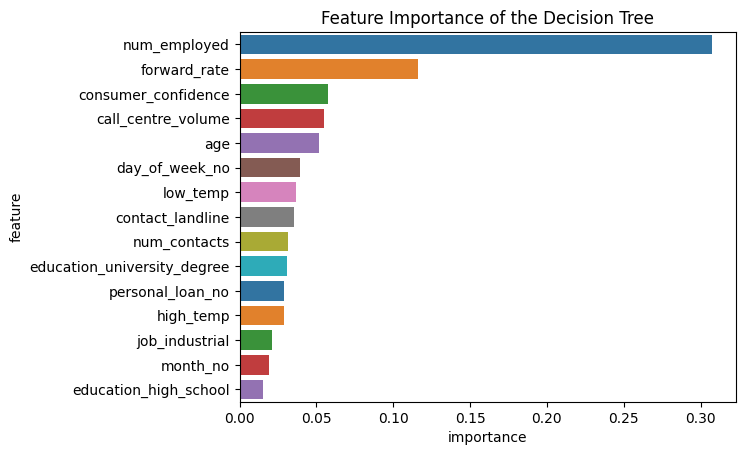

In [126]:
sns.barplot(data = importance_df.head(15), x = "importance", y = "feature",
            hue = "feature", legend = False, palette = "tab10")

plt.title("Feature Importance of the Decision Tree");

In [127]:
## Without Data Resampling
# Train Accuracy = 0.89018, Test Accuracy = 0.89718
# Recall = 0.21408045977011494, Precision = 0.59583

In [128]:
## Overfitted Model (With Smote)
# Train Accuracy = 1.00000, Test Accuracy = 0.81418
# Recall = 0.84354, Precision = 0.77580

In [129]:
## SMOTE Data Resampling
# Train Accuracy = 0.89418, Test Accuracy = 0.83461
# Recall = 0.84824, Precision = 0.82239

## 8.2 Random Forest

In [130]:
from sklearn.ensemble import RandomForestClassifier

model_random_forest = RandomForestClassifier(n_jobs = -1,
                                             n_estimators = 500,        # 500, 300, 600, 700
                                             max_features = 9,          # 7, 9, 11, 13, 15, 16    The best: 9   Max: 39
                                             max_depth = 35,            # 25, 30, 35
                                             min_samples_split = 2,
                                             random_state = 42)

model_random_forest.fit(train_inputs, train_targets)

train_preds_rforest = model_random_forest.predict(train_inputs)
test_preds_rforest = model_random_forest.predict(test_inputs)

train_acc = accuracy_score(train_targets, train_preds_rforest)

In [131]:
test_acc, recall_test, precision_test = calculate_basic_metrics(test_targets, test_preds_rforest)

print(f"Train Accuracy = {train_acc:.5f}, Test Accuracy = {test_acc:.5f}")
print(f"Recall = {recall_test:.5f}, Precision = {precision_test:.5f}")

Train Accuracy = 1.00000, Test Accuracy = 0.89590
Recall = 0.90316, Precision = 0.88792


In [132]:
#model_random_forest.estimators_

In [133]:
model_random_forest.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 35,
 'max_features': 9,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 500,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [134]:
importance_df = pd.DataFrame({
    "feature": train_inputs.columns,
    "importance": model_random_forest.feature_importances_
}).sort_values("importance", ascending = False)

importance_df.head(15)

,feature,importance
7,forward_rate,0.144546
4,call_centre_volume,0.100663
3,age,0.083397
8,num_employed,0.079215
5,high_temp,0.065535
6,low_temp,0.057663
11,employment_variation,0.049389
1,day_of_week_no,0.047530
2,num_contacts,0.042466
9,consumer_confidence,0.029307


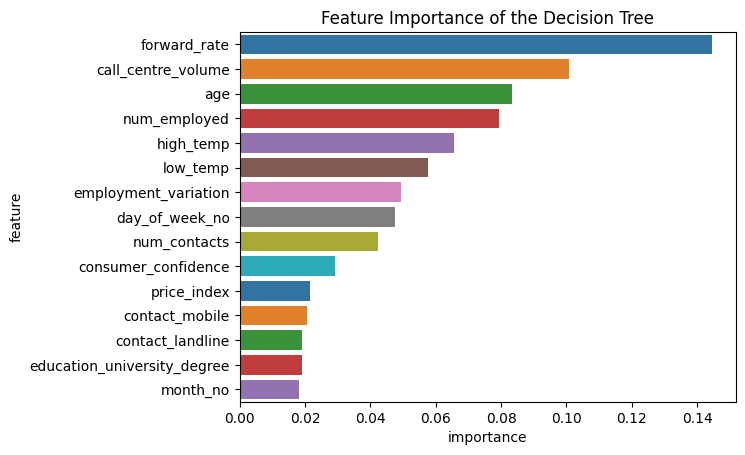

In [135]:
sns.barplot(data = importance_df.head(15), x = "importance", y = "feature",
            hue = "feature", legend = False, palette = "tab10")

plt.title("Feature Importance of the Decision Tree");

In [136]:
## Without Data Resampling
# Train Accuracy = 1.0, Test Accuracy = 0.89687
# Recall = 0.24282, Precision = 0.59583

In [137]:
## SMOTE Data Resampling
# Train Accuracy = 1.00000, Test Accuracy = 0.89590
# Recall = 0.90316, Precision = 0.88792

## 9. Gradient Boosting Model

In [138]:
%%time
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(max_depth = 10,                # 6-10
                              min_child_weight = 5,          # 2, 5
                              #gamma = 0,
                              n_estimators = 1000,
                              n_jobs = -1,
                              subsample = 1,                # 1, 0.93
                              #colsample_bytree = 1,
                              learning_rate = 0.1,           # 0.3-0.4
                              random_state = 42,
                              objective = "reg:squarederror",)      #reg:squarederror

xgboost_model.fit(train_inputs, train_targets)

train_preds_xgb = xgboost_model.predict(train_inputs)
test_preds_xgb = xgboost_model.predict(test_inputs)

CPU times: user 31.9 s, sys: 237 ms, total: 32.1 s
Wall time: 18 s


In [139]:
train_acc = accuracy_score(train_targets, train_preds_xgb)
test_acc, recall_test, precision_test = calculate_basic_metrics(test_targets, test_preds_xgb)

In [140]:
print(f"Train Accuracy = {train_acc:.5f}, Test Accuracy = {test_acc:.5f}")
print(f"Recall = {recall_test:.5}, Precision = {precision_test:.5f}")

Train Accuracy = 0.99984, Test Accuracy = 0.89536
Recall = 0.90967, Precision = 0.88210


In [141]:
## Without Data Resampling
# Train Accuracy = 0.90046, Test Accuracy = 0.90046
# Recall = 0.23450, Precision = 0.59583

In [142]:
## SMOTE Data Resampling
# Train Accuracy = 0.99984, Test Accuracy = 0.89536
# Recall = 0.90967, Precision = 0.8821